# Applying SPOD to PIV data

## Loading data

In [ ]:
from google.colab import drive
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.animation as animation
import scipy
from scipy.signal import get_window
from scipy.linalg import eigh
from numpy.fft import rfft
import os

In [ ]:
# Check if Google Drive is already mounted
if not os.path.exists('/content/drive'):
    # Mount Google Drive
    drive.mount('/content/drive')
else:
    print("Google Drive is already mounted.")


file_path = '/content/drive/My Drive/TFG_datos/RUN1_PIV_compressed.npz'

# Load the data from the .npz file
try:
    data = np.load(file_path)
    print("File loaded successfully!")
    # data['array_name']
    # To see what arrays are in the file, we use data.files
    print("Arrays in the .npz file:", data.files)

except FileNotFoundError:
    print(f"Error: The file was not found at {file_path}")
except Exception as e:
    print(f"An error occurred: {e}")

Mounted at /content/drive
File loaded successfully!
Arrays in the .npz file: ['X', 'Y', 'U', 'V']


In [ ]:
X = data['X']
Y = data['Y']
U = data['U']
V = data['V']

## SPOD computation

In [ ]:
def compute_spod(U, V, n_fft=256, overlap=None, window_type='hamming', n_modes=None):
    """
    SPOD using method of snapshots for memory efficiency (explained in Schmidt and Colonius, 2020)

    Parameters:
        U, V: arrays of shape (nt, nx, ny)
        n_fft: number of samples per block (e.g., 256)
        overlap: overlap between blocks (default: n_fft // 2)
        window_type: string (e.g., 'hamming')
        n_modes: int or None - number of leading modes to return

    Returns:
        freqs: ndarray of shape (n_freq,)
        eigvals: ndarray (n_freq, n_modes)
        eigvecs: ndarray (n_freq, n_modes, spatial_dof)
    """
    if overlap is None:
        overlap = n_fft // 2

    nt, nx, ny = U.shape
    spatial_dof = 2 * nx * ny # spatial degrees of freedom (called M in the paper)
    step = n_fft - overlap # how many realizations we advance per block
    n_blocks = (nt - overlap) // step
    n_freq = n_fft // 2 + 1

    if n_blocks < 2:
        raise ValueError("Not enough time blocks.")

    # Check that the wanted number of modes is valid (max modes = n_blocks)
    if n_modes is not None and n_modes > n_blocks:
      print(f"Warning: Requested n_modes={n_modes} exceeds number of blocks={n_blocks}. Reducing n_modes to {n_blocks}.")
      n_modes = n_blocks

    # Create window and normalization factor
    window = get_window(window_type, n_fft)
    window = window / np.sqrt(np.sum(window**2) / n_fft)  # normalize energy

    # Prepare array for Fourier realizations: shape (n_freq, n_blocks, spatial_dof)
    Q_hat = np.empty((n_freq, n_blocks, spatial_dof), dtype=np.complex64)

    # For each block, we flatten the spatial dimensions compute the FFT of each
    # realization of the block and store it in the Q_hat matrix
    for i in range(n_blocks):
        start = i * step
        end = start + n_fft
        u_block = U[start:end].reshape(n_fft, -1)
        v_block = V[start:end].reshape(n_fft, -1)
        block = np.concatenate((u_block, v_block), axis=1)
        block *= window[:, None]
        # Since the data we are using is real, we will use rfft() which will only output positive frequencies
        fft_block = rfft(block, axis=0)
        Q_hat[:, i, :] = fft_block  # shape (n_freq, spatial_dof)

    # Prepare arrays for eigenvalues and eigenvectors
    eigvals = np.zeros((n_freq, n_blocks if n_modes is None else n_modes))
    eigvecs = np.zeros((n_freq, n_blocks if n_modes is None else n_modes, spatial_dof), dtype=np.complex64)

    # Solution to the eigenvalue problem
    for f in range(n_freq):
        Qf = Q_hat[f]  # (n_blocks, spatial_dof)
        # (n_blocks - 1) for the unbiased estimate
        C = Qf @ Qf.conj().T / (n_blocks - 1)  # shape (n_blocks, n_blocks)

        # Eigen-decomposition
        lam, psi = eigh(C)
        idx = np.argsort(lam)[::-1]
        lam = lam[idx]
        psi = psi[:, idx]

        if n_modes is not None:
            lam = lam[:n_modes]
            psi = psi[:, :n_modes]

        eigvals[f, :len(lam)] = lam.real
        # project the eigenvectors from snapshot space into the full physical
        # space, obtaining the actual SPOD modes.
        eigvecs[f, :len(lam)] = (psi.T @ Qf).real / np.sqrt(lam[:, None])

    # d is the sampling spacing (time between snapshots). At the moment I don't know it, so we will leave it as 1 for now and use Hz/dt
    freqs = np.fft.rfftfreq(n_fft, d=1.0)
    return freqs, eigvals, eigvecs

In [ ]:
freqs, eigvals, eigvecs = compute_spod(U, V, n_fft=256)

## First Mode Plot

In [ ]:
def plot_spod_mode(X, Y, mode, title=None, scale=0.1, quiver_step=10, cmap="RdBu_r"):
    """
    Visualizes a 2D SPOD mode using a quiver plot.

    Parameters:
        X, Y: arrays of shape (nx, ny) - spatial coordinates
        mode: array of shape (2, nx, ny) - real part of SPOD mode [u_mode, v_mode]
        title: optional string - plot title
        scale: float - scale factor for quiver arrows
        quiver_step: int - step size for downsampling quiver grid
        cmap: str - colormap for background magnitude
    """
    u, v = mode[0], mode[1]
    mag = np.sqrt(u**2 + v**2)

    fig, ax = plt.subplots(figsize=(10, 6))
    cont = ax.contourf(X, Y, mag, cmap=cmap, levels=50)
    cbar = plt.colorbar(cont, ax=ax)
    cbar.set_label("Mode Magnitude")

    ax.quiver(
        X[::quiver_step, ::quiver_step],
        Y[::quiver_step, ::quiver_step],
        u[::quiver_step, ::quiver_step],
        v[::quiver_step, ::quiver_step],
        scale=scale, color="k", alpha=0.7
    )

    ax.set_title(title or "SPOD Mode")
    ax.set_xlabel("X")
    ax.set_ylabel("Y")
    ax.set_aspect("equal")
    plt.tight_layout()
    plt.show()


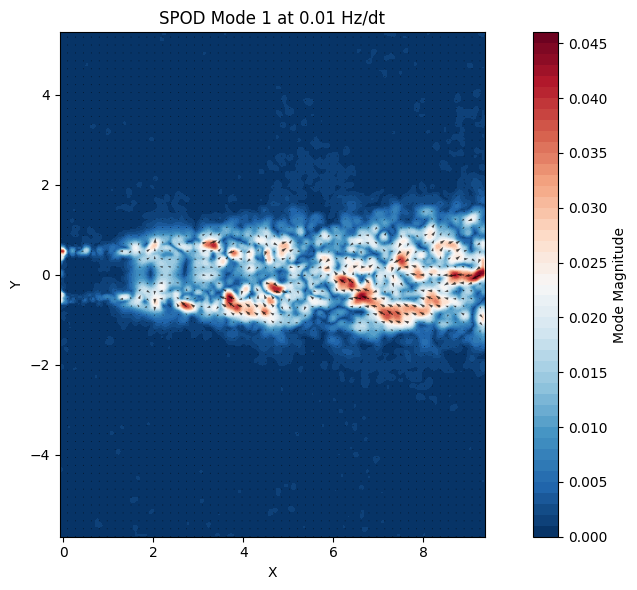

In [ ]:
f_target = 0.01  # target frequency in Hz/dt
f_idx = np.argmin(np.abs(freqs - f_target))  # closest freq

# Get real-valued mode and reshape
mode_vector = eigvecs[f_idx, 0].real  # shape (2 * nx * ny,)
nx, ny = X.shape
mode_reshaped = mode_vector.reshape(2, nx, ny)

plot_spod_mode(X, Y, mode_reshaped,
               title=f"SPOD Mode 1 at {freqs[f_idx]:.2f} Hz/dt",
               scale=2, quiver_step=5)


## Energy Spectrum Analysis

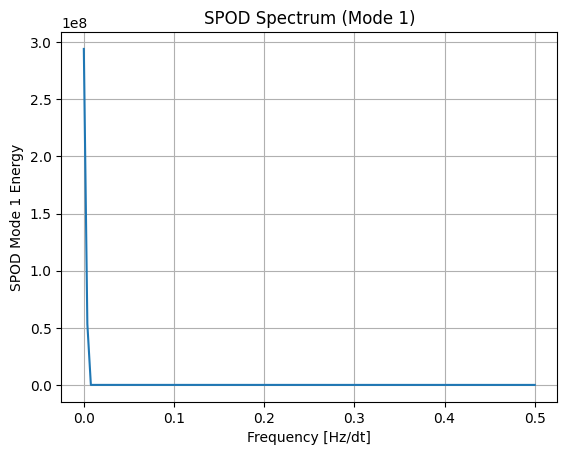

In [ ]:
plt.plot(freqs, eigvals[:, 0]) # mode 1
plt.xlabel("Frequency [Hz/dt]")
plt.ylabel("SPOD Mode 1 Energy")
plt.title("SPOD Spectrum (Mode 1)")
plt.grid()

There is a peak at low frequencies

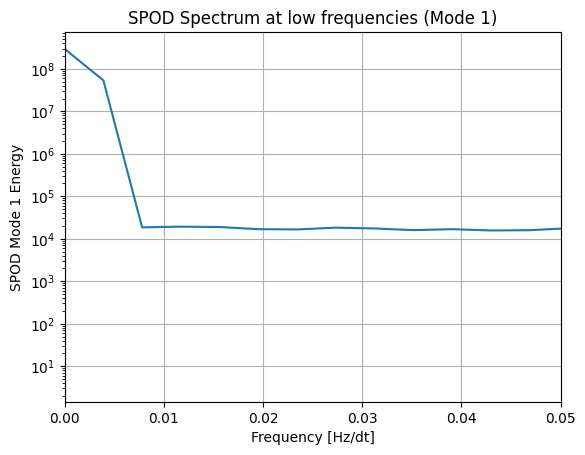

In [ ]:
plt.plot(freqs, eigvals[:, 0])  # mode 1
plt.xlabel("Frequency [Hz/dt]")
plt.ylabel("SPOD Mode 1 Energy")
plt.title("SPOD Spectrum at low frequencies (Mode 1)")
plt.xlim(0, 0.05)
plt.yscale("log")
plt.grid()

First two frequencies correspond to most of the energy. This is explained by the fact that we have computed SPOD with the raw data (U, V) instead of the fluctuations, so most of the energy corresponds to the mean flow and corresponds to the big spike at f=0. To filter this non-informative part, I should have computed SPOD with the fluctuations (u, v) instead of the raw data.

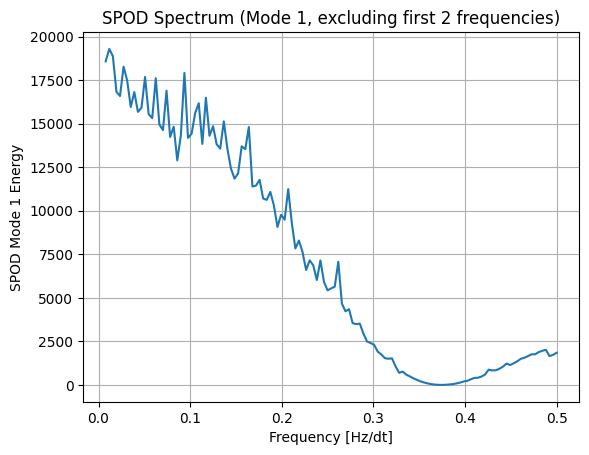

In [ ]:
# Skip the first two frequency bins
freqs_skipped = freqs[2:]
mode1_energy_skipped = eigvals[2:, 0]  # mode 1 energy, skip first 2 frequencies

# Plot
plt.plot(freqs_skipped, mode1_energy_skipped)
plt.xlabel("Frequency [Hz/dt]")
plt.ylabel("SPOD Mode 1 Energy")
plt.title("SPOD Spectrum (Mode 1, excluding first 2 frequencies)")
plt.grid()

## SPOD mode energy spectrum at a fixed frequency

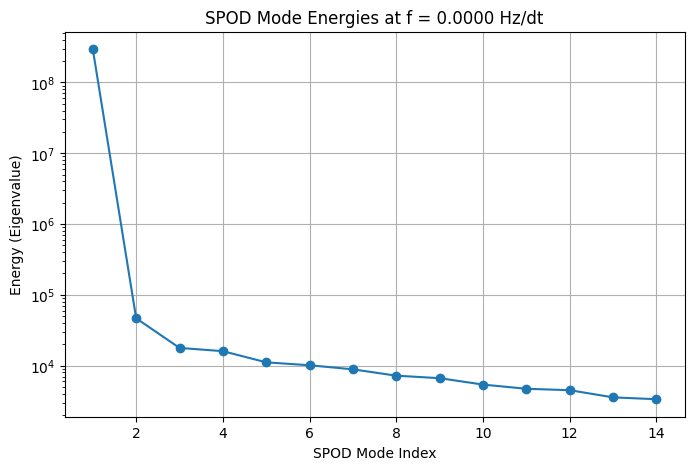

In [ ]:
f_target = 0.000
f_idx = np.argmin(np.abs(freqs - f_target))  # Find closest frequency index

# Extract eigenvalues at this frequency
mode_energies = eigvals[f_idx, :]

# Plot
plt.figure(figsize=(8, 5))
plt.plot(np.arange(1, len(mode_energies) + 1), mode_energies, marker='o')
plt.xlabel("SPOD Mode Index")
plt.ylabel("Energy (Eigenvalue)")
plt.title(f"SPOD Mode Energies at f = {freqs[f_idx]:.4f} Hz/dt")
plt.yscale("log")
plt.grid()

After analyzing the mode energy spectrum at different frequencies, we see that the first mode of the first two frequencies correspond to most of the energy. 